##Imports

In [81]:
import pandas as pd
import numpy as np
import requests
import warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
%matplotlib inline

## team details

In [82]:

ML_CHOICE = 'Random Forest'
# Options: 'composite'  | 'Random Forest'  | 'Linear Regression'

# Formation options: '4-4-2' | '4-3-3' | '3-5-2' | '5-3-2' | '4-5-1' | '3-4-3'
FORMATION = '4-3-3'

# Picking strategy options:
#   'greedy'   - highest score per position
#   'value'    - best pts per £m (finds cheap gems)
#   'form'     - best recent FPL form
#   'balanced' - blend of score, value, form and fixture difficulty
#   'fixture'  - easiest upcoming fixtures
STRATEGY = 'balanced'

# Player filters
MIN_MINUTES  = 200    # exclude players with fewer minutes
MAX_PRICE    = 15.0   # exclude players above this price (£m)
LOAD_HISTORY = False  # set True to fetch per-GW history (slower but more accurate)

# Budget & squad rules
BUDGET        = 100.0
SUBS          = 4
MAX_SAME_CLUB = 3

print(f'Model: {ML_CHOICE} | Formation: {FORMATION} | Strategy: {STRATEGY}')


Model: Random Forest | Formation: 4-3-3 | Strategy: balanced


## Costants


In [83]:
FPL_BASE = 'https://fantasy.premierleague.com/api'

POSITION_MAP    = {1: 'GKP', 2: 'DEF', 3: 'MID', 4: 'FWD'}
POSITION_COLORS = {'GKP': '#f5a623', 'DEF': '#00b2ff', 'MID': '#04f5ff', 'FWD': '#e90052'}

FORMATION_OPTS = {
    '4-4-2': (1, 4, 4, 2), '4-3-3': (1, 4, 3, 3),
    '3-5-2': (1, 3, 5, 2), '5-3-2': (1, 5, 3, 2),
    '4-5-1': (1, 4, 5, 1), '3-4-3': (1, 3, 4, 3),
}

DISPLAY_COLS = [
    'web_name', 'team_name', 'position', 'price', 'total_points',
    'form', 'goals_scored', 'assists', 'expected_goals', 'expected_assists',
    'bonus', 'minutes', 'avg_fdr_next5',
]

BG = '#0f1923'   # shared dark background for all charts

# shared axis styling helper
def style_ax(ax, title):
    ax.set_facecolor(BG)
    ax.set_title(title, fontsize=13, fontweight='bold', color='white', pad=10)
    ax.tick_params(colors='white', labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#ffffff33')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

# consistent team colour palette
TAB20_COLORS = (
    sns.color_palette('tab20', 20) +
    sns.color_palette('tab20b', 20)
)
def team_color_map(teams):
    return {t: TAB20_COLORS[i % len(TAB20_COLORS)] for i, t in enumerate(sorted(teams))}


## API calls

In [84]:
def load_bootstrap():
    r = requests.get(f'{FPL_BASE}/bootstrap-static/', timeout=20)
    r.raise_for_status()
    return r.json()

def load_fixtures():
    r = requests.get(f'{FPL_BASE}/fixtures/', timeout=20)
    r.raise_for_status()
    return r.json()

def load_player_histories(player_ids):
    """Fetch per-gameweek history for all players (~700 API calls, takes a few minutes)."""
    rows = []
    for i, pid in enumerate(player_ids):
        if i % 100 == 0:
            print(f'  Fetching history: {i}/{len(player_ids)} players...')
        try:
            r = requests.get(f'{FPL_BASE}/element-summary/{pid}/', timeout=10)
            if r.status_code == 200:
                for gw in r.json().get('history', []):
                    gw['element'] = pid
                    rows.append(gw)
        except Exception:
            continue
    return pd.DataFrame(rows)

# --- fetch ---
print('Fetching bootstrap data...')
bootstrap = load_bootstrap()
print(f'  Players: {len(bootstrap["elements"])}  |  Teams: {len(bootstrap["teams"])}')

print('Fetching fixtures...')
try:
    fixtures = load_fixtures()
    print(f'  Fixtures: {len(fixtures)}')
except Exception as e:
    print(f'  Fixtures unavailable ({e}) — FDR defaulting to 3')
    fixtures = []

history_df = pd.DataFrame()
if LOAD_HISTORY:
    ids = [p['id'] for p in bootstrap['elements']]
    history_df = load_player_histories(ids)
    print(f'  History rows: {len(history_df):,}')
else:
    print('History loading skipped (LOAD_HISTORY=False)')


Fetching bootstrap data...
  Players: 819  |  Teams: 20
Fetching fixtures...
  Fixtures: 380
History loading skipped (LOAD_HISTORY=False)


## Full player data

In [85]:
show_cols = [c for c in DISPLAY_COLS + [
    'xG_per90', 'xA_per90', 'pts_per_million', 'fdr_score', 'composite_score'
] if c in df.columns]

full_table = (df[show_cols]
              .sort_values('total_points', ascending=False)
              .reset_index(drop=True))
full_table.index = full_table.index + 1
full_table.head(30)


,web_name,team_name,position,price,total_points,form,goals_scored,assists,expected_goals,expected_assists,bonus,minutes,avg_fdr_next5,xG_per90,xA_per90,pts_per_million,fdr_score,composite_score
1,Haaland,MCI,FWD,14.7,193,5.4,22,7,20.66,1.86,35,2233,3.0,0.832691,0.074966,13.129252,2.0,36.980157
2,Semenyo,MCI,MID,8.2,165,7.0,14,6,9.58,2.29,17,2426,3.0,0.355400,0.084955,20.121951,2.0,48.514276
3,B.Fernandes,MUN,MID,10.0,158,7.4,7,13,9.05,7.16,28,2165,3.2,0.376212,0.297644,15.800000,1.8,43.602490
4,Rice,ARS,MID,7.5,157,5.6,4,9,2.99,6.22,21,2400,3.4,0.112125,0.233250,20.933333,1.6,46.249969
5,Gabriel,ARS,DEF,7.1,153,4.8,3,4,1.87,1.59,21,1985,3.4,0.084786,0.072091,21.549296,1.6,45.254746
6,Thiago,BRE,FWD,7.2,141,3.4,18,1,15.64,1.58,19,2382,2.6,0.590932,0.059698,19.583333,2.4,41.641223
7,João Pedro,CHE,FWD,7.6,141,6.8,11,8,10.57,1.72,25,2056,3.4,0.462695,0.075292,18.552632,1.6,46.055692
8,Wilson,FUL,MID,6.0,140,5.2,9,8,4.69,3.92,19,2086,2.8,0.202349,0.169128,23.333333,2.2,49.764517
9,J.Timber,ARS,DEF,6.3,135,4.0,3,5,4.71,1.45,7,2325,3.4,0.182323,0.056129,21.428571,1.6,43.118282
10,Bruno G.,NEW,MID,6.8,134,3.5,9,6,4.82,3.62,19,2019,3.0,0.214859,0.161367,19.705882,2.0,40.759721


## Feature engineering


`goals_per90`, `assists_per90` | Rate stats per 90 minutes played |

`xG_per90`, `xA_per90` | Expected goals / assists per 90 |

`bonus_per90` | Bonus points per 90 |

`pts_per_million` | Total points divided by price — the value metric |

`availability` | Fraction of possible minutes played this season |

`avg_fdr_next5` | Average fixture difficulty over the next 5 gameweeks |

`fdr_score` | Inverted FDR (5 = easiest schedule) |

`composite_score` | Weighted hand-crafted formula combining all key metrics |


In [86]:
def build_features(bootstrap, history_df, fixtures):
    players  = pd.DataFrame(bootstrap['elements'])
    teams_df = pd.DataFrame(bootstrap['teams'])

    players['position'] = players['element_type'].map(POSITION_MAP)
    players['price']    = players['now_cost'] / 10

    num_cols = [
        'goals_scored', 'assists', 'clean_sheets', 'minutes',
        'yellow_cards', 'red_cards', 'saves', 'bonus', 'bps',
        'influence', 'creativity', 'threat', 'ict_index',
        'expected_goals', 'expected_assists',
        'expected_goal_involvements', 'expected_goals_conceded',
        'form', 'points_per_game', 'selected_by_percent',
        'transfers_in', 'transfers_out', 'total_points',
        'value_season', 'goals_conceded', 'own_goals',
    ]
    for c in num_cols:
        if c in players.columns:
            players[c] = pd.to_numeric(players[c], errors='coerce')
    players[[c for c in num_cols if c in players.columns]] = \
        players[[c for c in num_cols if c in players.columns]].fillna(0)

    safe = players['minutes'].replace(0, np.nan)
    players['goals_per90']     = (players['goals_scored']    / safe * 90).fillna(0)
    players['assists_per90']   = (players['assists']          / safe * 90).fillna(0)
    players['xG_per90']        = (players.get('expected_goals',   0) / safe * 90).fillna(0)
    players['xA_per90']        = (players.get('expected_assists',  0) / safe * 90).fillna(0)
    players['bonus_per90']     = (players['bonus']            / safe * 90).fillna(0)
    players['pts_per_million'] = (players['total_points'] / players['price'].replace(0, np.nan)).fillna(0)
    players['form']            = pd.to_numeric(players['form'], errors='coerce').fillna(0)
    players['availability']    = players['minutes'] / (players['minutes'].max() + 1)
    players['appearances']     = (players['minutes'] / 90).apply(np.floor).astype(int)

    # fixture difficulty
    next_gws = [f for f in fixtures if not f.get('finished', True)][:50]
    team_fdr = {}
    for f in next_gws:
        team_fdr.setdefault(f['team_h'], []).append(f.get('team_h_difficulty', 3))
        team_fdr.setdefault(f['team_a'], []).append(f.get('team_a_difficulty', 3))
    players['avg_fdr_next5'] = players['team'].apply(
        lambda tid: float(np.mean(team_fdr.get(tid, [3])[:5]))
    )
    players['fdr_score'] = 5 - players['avg_fdr_next5']

    # history aggregates (needs LOAD_HISTORY=True)
    if not history_df.empty and len(history_df) >= 15000:
        hcols = {'total_points': 'h_avg_pts', 'minutes': 'h_avg_min',
                 'goals_scored': 'h_goals', 'assists': 'h_assists', 'bonus': 'h_bonus'}
        for s in hcols:
            if s in history_df.columns:
                history_df[s] = pd.to_numeric(history_df[s], errors='coerce').fillna(0)
        agg = history_df.groupby('element').agg(
            {s: 'mean' for s in hcols if s in history_df.columns}
        ).rename(columns=hcols)
        players = players.merge(agg, left_on='id', right_index=True, how='left')
        for dst in hcols.values():
            if dst in players.columns:
                players[dst] = players[dst].fillna(players[dst].median())
    else:
        for dst in ['h_avg_pts', 'h_avg_min', 'h_goals', 'h_assists', 'h_bonus']:
            players[dst] = 0

    # composite score (used when ML_CHOICE = 'composite')
    players['composite_score'] = (
        players['form']            * 2.0 +
        players['pts_per_million'] * 1.5 +
        players['fdr_score']       * 1.0 +
        players['xG_per90']        * 3.0 +
        players['xA_per90']        * 2.0 +
        players['bonus_per90']     * 1.0 +
        players['availability']    * 0.5
    )

    players['web_name']  = players['web_name'].fillna(
        players['first_name'] + ' ' + players['second_name'])
    players['team_name'] = players['team'].map(
        teams_df.set_index('id')['short_name'].to_dict()).fillna('UNK')
    return players

df = build_features(bootstrap, history_df, fixtures)
print(f'Feature matrix: {df.shape[0]} players x {df.shape[1]} columns')
df[DISPLAY_COLS].head(10)


Feature matrix: 819 players x 122 columns


,web_name,team_name,position,price,total_points,form,goals_scored,assists,expected_goals,expected_assists,bonus,minutes,avg_fdr_next5
0,Raya,ARS,GKP,6.0,115,3.2,0,0,0.00,0.06,5,2610,3.4
1,Arrizabalaga,ARS,GKP,4.1,0,0.0,0,0,0.00,0.00,0,0,3.4
2,Hein,ARS,GKP,4.0,0,0.0,0,0,0.00,0.00,0,0,3.4
3,Setford,ARS,GKP,3.9,0,0.0,0,0,0.00,0.00,0,0,3.4
4,Gabriel,ARS,DEF,7.1,153,4.8,3,4,1.87,1.59,21,1985,3.4
5,Saliba,ARS,DEF,6.1,96,4.0,1,0,0.88,0.61,6,1984,3.4
6,Calafiori,ARS,DEF,5.6,86,1.6,1,2,2.77,0.40,4,1347,3.4
7,J.Timber,ARS,DEF,6.3,135,4.0,3,5,4.71,1.45,7,2325,3.4
8,Kiwior,ARS,DEF,5.4,0,0.0,0,0,0.00,0.00,0,0,3.4
9,Lewis-Skelly,ARS,DEF,5.1,12,0.0,0,0,0.05,0.06,0,311,3.4


## Machine learning

In [87]:
FEATURE_COLS = [
    'goals_scored', 'assists', 'clean_sheets', 'minutes', 'bonus', 'bps',
    'form', 'goals_per90', 'assists_per90', 'xG_per90', 'xA_per90',
    'bonus_per90', 'fdr_score', 'availability', 'pts_per_million',
    'h_avg_pts', 'h_avg_min', 'h_goals', 'h_assists', 'h_bonus',
]

# filter players
df_filtered = df[(df['minutes'] >= MIN_MINUTES) & (df['price'] <= MAX_PRICE)].copy()
print(f'Players after filtering: {len(df_filtered)}')

# prepare data
feat_cols = [c for c in FEATURE_COLS if c in df_filtered.columns]
X = df_filtered[feat_cols].fillna(0)
y = df_filtered['total_points']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler  = StandardScaler()
X_tr_s  = scaler.fit_transform(X_train)
X_te_s  = scaler.transform(X_test)

# train both models
models_def = {
    'Random Forest':    RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    'Linear Regression': LinearRegression(),
}

trained_models = {}
for name, model in models_def.items():
    print(f'Training {name}...')
    model.fit(X_tr_s, y_train)
    pred = model.predict(X_te_s)
    trained_models[name] = {
        'model': model,
        'mae':   mean_absolute_error(y_test, pred),
        'r2':    r2_score(y_test, pred),
    }
    print(f'  MAE = {trained_models[name]["mae"]:.2f}   R² = {trained_models[name]["r2"]:.3f}')


Players after filtering: 419
Training Random Forest...
  MAE = 5.25   R² = 0.935
Training Linear Regression...
  MAE = 3.81   R² = 0.980


In [88]:
# side-by-side comparison
results_df = pd.DataFrame([
    {'Model': name, 'MAE': round(info['mae'], 2), 'R²': round(info['r2'], 3)}
    for name, info in trained_models.items()
])
print('\nModel Comparison:')
results_df



Model Comparison:


,Model,MAE,R²
0,Random Forest,5.25,0.935
1,Linear Regression,3.81,0.980


In [89]:
# score all players with the chosen model
score_col = 'composite_score'

if ML_CHOICE in trained_models:
    X_all = scaler.transform(df_filtered[feat_cols].fillna(0))
    df_filtered = df_filtered.copy()
    df_filtered['ml_score'] = trained_models[ML_CHOICE]['model'].predict(X_all)
    score_col = 'ml_score'
    print(f'Players scored with: {ML_CHOICE}')
else:
    print('Using composite score (no ML)')


Players scored with: Random Forest


## Selecting optimal squad

The picker respects three hard constraints:
- **£100m** total budget
- **Max 3 players** from the same club
- **1 GK starting, 1 GK on bench**


In [90]:
PICK_STRATEGIES = {
    'greedy':   'pick_score = score',
    'value':    'pick_score = pts_per_million',
    'form':     'pick_score = form',
    'balanced': 'normalised blend: 40% score + 25% value + 20% form + 15% fixture',
    'fixture':  'pick_score = fdr_score (easiest upcoming games)',
}

def _apply_strategy(df, score_col, strategy):
    df = df.copy()
    if strategy == 'greedy':
        df['pick_score'] = df[score_col]
    elif strategy == 'value':
        df['pick_score'] = df['pts_per_million']
    elif strategy == 'form':
        df['pick_score'] = df['form']
    elif strategy == 'fixture':
        df['pick_score'] = df['fdr_score']
    else:  # balanced
        def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
        df['pick_score'] = (
            norm(df[score_col])         * 0.40 +
            norm(df['pts_per_million']) * 0.25 +
            norm(df['form'])            * 0.20 +
            norm(df['fdr_score'])       * 0.15
        )
    return df

def pick_team(df, formation, score_col, strategy='greedy'):
    df       = _apply_strategy(df, score_col, strategy)
    gkp_n, def_n, mid_n, fwd_n = FORMATION_OPTS[formation]
    budget   = BUDGET
    club_cnt = {}

    def pick_pos(pos, n_start, n_bench, pool):
        nonlocal budget
        pool = pool[pool['position'] == pos].copy()
        pool = pool[pool['price'] <= budget].sort_values('pick_score', ascending=False)
        starters, bench = [], []
        for _, row in pool.iterrows():
            if club_cnt.get(row['team_name'], 0) >= MAX_SAME_CLUB:
                continue
            if len(starters) < n_start:
                starters.append(row)
                club_cnt[row['team_name']] = club_cnt.get(row['team_name'], 0) + 1
                budget -= row['price']
            elif len(bench) < n_bench:
                bench.append(row)
                club_cnt[row['team_name']] = club_cnt.get(row['team_name'], 0) + 1
                budget -= row['price']
            if len(starters) == n_start and len(bench) == n_bench:
                break
        return starters, bench

    rem = df.copy()
    gk_st, gk_bn = pick_pos('GKP', 1, 1, rem)
    rem = rem[~rem['id'].isin({r['id'] for r in gk_st + gk_bn})]
    def_st, _ = pick_pos('DEF', def_n, 0, rem)
    rem = rem[~rem['id'].isin({r['id'] for r in def_st})]
    mid_st, _ = pick_pos('MID', mid_n, 0, rem)
    rem = rem[~rem['id'].isin({r['id'] for r in mid_st})]
    fwd_st, _ = pick_pos('FWD', fwd_n, 0, rem)
    rem = rem[~rem['id'].isin({r['id'] for r in fwd_st})]

    bench_out = []
    for pos in ['DEF', 'MID', 'FWD']:
        if len(bench_out) >= SUBS - 1: break
        pool = rem[rem['position'] == pos]
        pool = pool[pool['price'] <= budget].sort_values('pick_score', ascending=False)
        for _, row in pool.iterrows():
            if len(bench_out) >= SUBS - 1: break
            if club_cnt.get(row['team_name'], 0) >= MAX_SAME_CLUB: continue
            bench_out.append(row)
            club_cnt[row['team_name']] = club_cnt.get(row['team_name'], 0) + 1
            budget -= row['price']
            rem = rem[rem['id'] != row['id']]

    return pd.DataFrame(gk_st + def_st + mid_st + fwd_st), pd.DataFrame(gk_bn + bench_out)


In [91]:
starters, bench = pick_team(df_filtered, FORMATION, score_col, STRATEGY)

cols       = [c for c in DISPLAY_COLS if c in starters.columns]
bench_cols = [c for c in DISPLAY_COLS if c in bench.columns]

full = pd.concat([starters[cols], bench[bench_cols]], ignore_index=True)
full.insert(0, 'Role', ['Starter'] * len(starters) + ['Bench'] * len(bench))
full.index = full.index + 1

total = pd.concat([starters, bench])['price'].sum()
print(f'Formation : {FORMATION}')
print(f'Model     : {ML_CHOICE}')
print(f'Strategy  : {STRATEGY}')
print(f'Total cost: £{total:.1f}m  (£{BUDGET - total:.1f}m remaining)')
print(f'Squad size: {len(starters)} starters + {len(bench)} bench')
print()
full


Formation : 4-3-3
Model     : Random Forest
Strategy  : balanced
Total cost: £88.9m  (£11.1m remaining)
Squad size: 11 starters + 4 bench



,Role,web_name,team_name,position,price,total_points,form,goals_scored,assists,expected_goals,expected_assists,bonus,minutes,avg_fdr_next5
1,Starter,Henderson,CRY,GKP,5.0,112,6.0,0,0,0.00,0.10,7,2520,3.0
2,Starter,Virgil,LIV,DEF,6.1,129,8.8,3,1,2.22,0.91,9,2520,2.6
3,Starter,O'Reilly,MCI,DEF,5.1,123,7.8,4,3,3.36,1.68,6,2040,3.0
4,Starter,Guéhi,MCI,DEF,5.2,132,4.2,2,4,2.86,2.05,9,2340,3.0
5,Starter,Matheus N.,MCI,DEF,5.4,125,4.0,1,7,0.25,1.71,16,2084,3.0
6,Starter,Wilson,FUL,MID,6.0,140,5.2,9,8,4.69,3.92,19,2086,2.8
7,Starter,Gravenberch,LIV,MID,5.5,119,4.5,4,5,1.39,1.89,13,2293,2.6
8,Starter,Anderson,NFO,MID,5.4,119,4.4,1,3,2.35,3.09,7,2506,2.8
9,Starter,Thiago,BRE,FWD,7.2,141,3.4,18,1,15.64,1.58,19,2382,2.6
10,Starter,Ekitiké,LIV,FWD,9.1,121,5.2,11,4,9.54,2.02,22,1674,2.6


## Visualisations

###Goals + Assists — top involvement

In [92]:
# Goals + Assists — stacked horizontal bar (top 15 by involvement)
plot_df = df.copy()
plot_df['involvement'] = plot_df['goals_scored'] + plot_df['assists']
top = (plot_df.nlargest(15, 'involvement')
              [['web_name', 'goals_scored', 'assists']]
              .sort_values('goals_scored'))


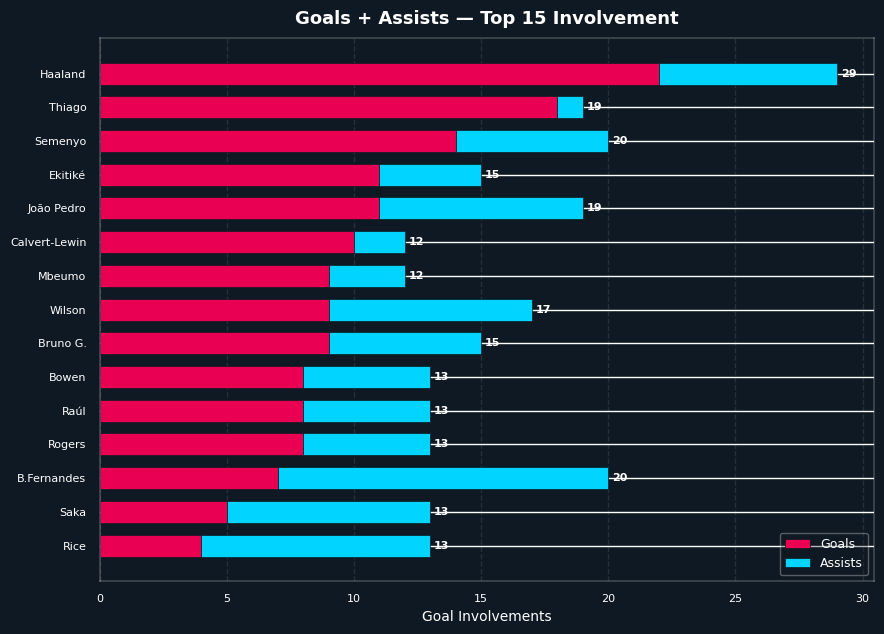

In [93]:

fig, ax = plt.subplots(figsize=(9, 6.5))
fig.patch.set_facecolor(BG)
y = range(len(top))

ax.barh(list(y), top['goals_scored'], color='#e90052', label='Goals',
        edgecolor=BG, linewidth=0.5, height=0.65)
ax.barh(list(y), top['assists'], left=top['goals_scored'],
        color='#00d4ff', label='Assists', edgecolor=BG, linewidth=0.5, height=0.65)

totals = top['goals_scored'] + top['assists']
for val, yi in zip(totals, y):
    ax.text(val + 0.15, yi, str(int(val)), va='center',
            fontsize=8, color='white', fontweight='bold')

ax.set_yticks(list(y))
ax.set_yticklabels(top['web_name'], fontsize=8.5)
ax.set_xlabel('Goal Involvements', fontsize=10)
style_ax(ax, 'Goals + Assists — Top 15 Involvement')
ax.legend(fontsize=9, framealpha=0.3, labelcolor='white',
          facecolor=BG, edgecolor='#ffffff33')
ax.grid(axis='x', color='white', alpha=0.1, linestyle='--')
plt.tight_layout()
plt.show()


### Average points, price & value by position

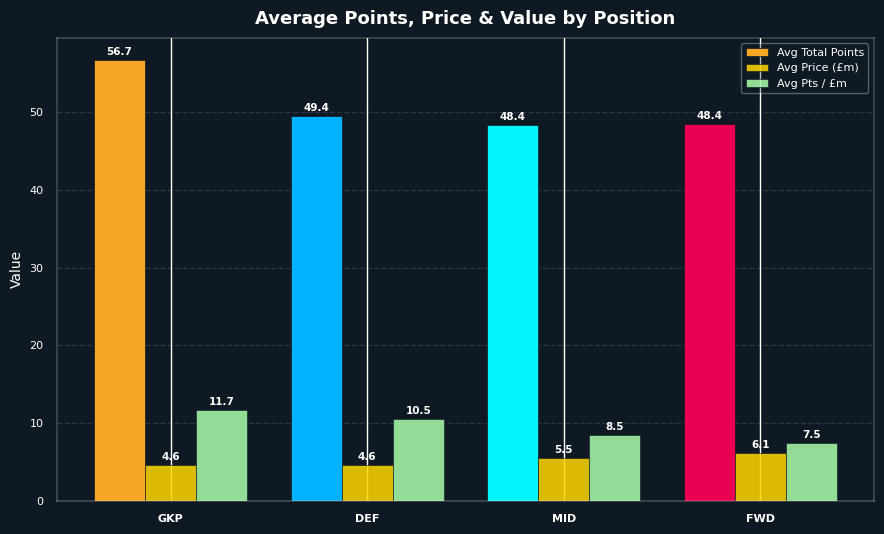

In [94]:
pos_order = ['GKP', 'DEF', 'MID', 'FWD']
agg = (df[df['total_points'] > 0]
       .groupby('position')[['total_points', 'price', 'pts_per_million']]
       .mean().reindex(pos_order).dropna())

x, w = np.arange(len(agg)), 0.26
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor(BG)

b1 = ax.bar(x - w, agg['total_points'], w, label='Avg Total Points',
            color=[POSITION_COLORS.get(p, '#888') for p in agg.index],
            edgecolor=BG, linewidth=0.5)
b2 = ax.bar(x,     agg['price'],        w, label='Avg Price (£m)',
            color='#FFD700', edgecolor=BG, linewidth=0.5, alpha=0.85)
b3 = ax.bar(x + w, agg['pts_per_million'], w, label='Avg Pts / £m',
            color='#aaffaa', edgecolor=BG, linewidth=0.5, alpha=0.85)

for bars in (b1, b2, b3):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.4,
                f'{h:.1f}', ha='center', va='bottom',
                fontsize=7.5, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(agg.index, fontsize=11, fontweight='bold')
ax.set_ylabel('Value', fontsize=10)
style_ax(ax, 'Average Points, Price & Value by Position')
ax.yaxis.grid(True, color='white', alpha=0.12, linestyle='--')
ax.legend(fontsize=8, framealpha=0.3, labelcolor='white',
          facecolor=BG, edgecolor='#ffffff33')
plt.tight_layout()
plt.show()


### Average stats heatmap by position

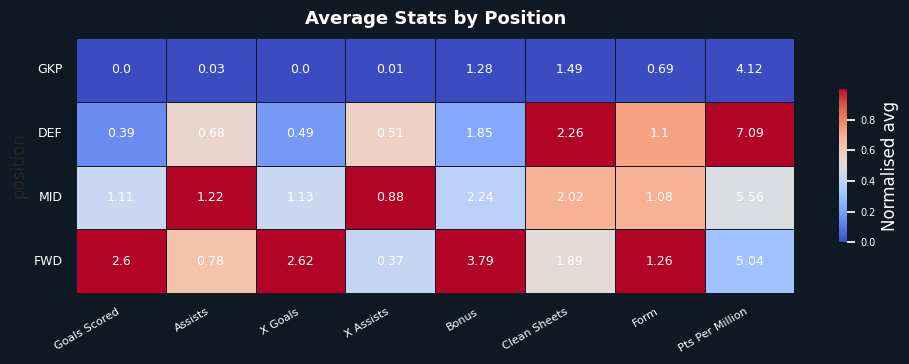

In [95]:
stat_cols = [c for c in ['goals_scored', 'assists', 'expected_goals', 'expected_assists',
                          'bonus', 'clean_sheets', 'form', 'pts_per_million']
             if c in df.columns]
agg = (df.groupby('position')[stat_cols].mean()
         .reindex(['GKP', 'DEF', 'MID', 'FWD']).dropna(how='all'))
norm_agg = (agg - agg.min()) / (agg.max() - agg.min() + 1e-9)
x_labels = [c.replace('_', ' ').replace('expected', 'x').title()
             for c in agg.columns]

fig, ax = plt.subplots(figsize=(10, 3.8))
fig.patch.set_facecolor(BG)

sns.heatmap(
    norm_agg, annot=agg.round(2).astype(str), fmt='', ax=ax,
    cmap='coolwarm', linewidths=0.5, linecolor=BG,
    cbar_kws={'shrink': 0.6, 'label': 'Normalised avg'},
    annot_kws={'size': 9, 'color': 'white'},
)
ax.set_title('Average Stats by Position', fontsize=13,
             fontweight='bold', color='white', pad=10)
ax.tick_params(colors='white', labelsize=9)
ax.set_xticklabels(x_labels, rotation=30, ha='right', color='white', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, color='white')
ax.collections[0].colorbar.ax.tick_params(colors='white', labelsize=7)
ax.collections[0].colorbar.ax.yaxis.label.set_color('white')
plt.tight_layout()
plt.show()
